# Kaggle scoring with score detrending

**Goal.** Evaluate whether rolling-median score detrending (`score_windows_detrended` from `scorer.py`) improves **ESA F0.5** over the baseline scoring, measured on a **labeled proxy** for the Kaggle test set. The best performer is then written as a Kaggle submission.

**Setup.** Two chronological windows at the tail of `train.parquet` stand in for val and Kaggle-test:
- `proxy_test = train_full[-521_280:]` — same length as `test.parquet`, last full block, labelled.
- `val        = train_full[-2*521_280 : -521_280]` — the block immediately before, labelled. Used only for threshold tuning.
- The real `test.parquet` (`test_scaled.npy`) is scored only for the final submission.

**Variants compared (6 rows in the table):**

| model   | baseline                         | detrended (median)                 | detrended (zscore)                |
|---      |---                               |---                                 |---                                |
| PCA     | `score_windows(topk=None)`       | `score_windows_detrended(..."median")` | `score_windows_detrended(..."zscore")` |
| LSTM-AE | `score_windows(topk=5)`          | same with detrend                  | same with detrend                 |

For every variant we tune the threshold on its own val output, then evaluate on the proxy-test. The old `PCA_THRESHOLD` / `LSTM_THRESHOLD` from `params.py` are **not** reused — the detrend subtraction changes the score distribution so old thresholds are meaningless.

**Per-split detrending.** The detrender is applied separately to val and proxy-test. Never concatenate them before detrending — the rolling baseline would leak across the split boundary and wash out exactly the regime change we're trying to correct for.

## Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    PCA_THRESHOLD, LSTM_THRESHOLD,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import score_windows, score_windows_detrended
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05
from sentinel.ml_logic.data       import find_anomaly_segments
from kaggle.submission            import make_submission, default_submission_path, submission_summary

sns.set_style('whitegrid')

KAGGLE_LEN = 521_280
KAGGLE_DIR = PROCESSED_DIR / 'kaggle'
print(f'KAGGLE_DIR        : {KAGGLE_DIR}')
print(f'PCA_THRESHOLD ref : {PCA_THRESHOLD}')
print(f'LSTM_THRESHOLD ref: {LSTM_THRESHOLD}')
print('(reference only — detrended variants get their own threshold)')

KAGGLE_DIR        : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
PCA_THRESHOLD ref : 0.060404
LSTM_THRESHOLD ref: 1.323612
(reference only — detrended variants get their own threshold)


## Load arrays + carve proxy splits

`train_full_scaled` is memory-mapped, and the two slices we actually score (`val`, `proxy_test`) are materialised as contiguous float32 arrays so TensorFlow can iterate over them without the mmap overhead.

In [2]:
train_full  = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
y_train_row = np.load(KAGGLE_DIR / 'y_train_row.npy')
test_scaled = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids    = np.load(KAGGLE_DIR / 'test_ids.npy')

n_full = len(train_full)
proxy_start = n_full - KAGGLE_LEN
val_start   = proxy_start - KAGGLE_LEN
assert val_start >= 0, 'train_full shorter than 2x KAGGLE_LEN'

X_val      = np.ascontiguousarray(train_full[val_start:proxy_start]).astype(np.float32)
y_val      = y_train_row[val_start:proxy_start].astype(np.int8)
X_proxy    = np.ascontiguousarray(train_full[proxy_start:]).astype(np.float32)
y_proxy    = y_train_row[proxy_start:].astype(np.int8)
X_kaggle   = test_scaled.astype(np.float32, copy=False)

print(f'train_full_scaled : {train_full.shape}')
print(f'val  slice        : {X_val.shape}    anomalies={int(y_val.sum()):,}   [{val_start:,}:{proxy_start:,})')
print(f'proxy_test slice  : {X_proxy.shape}  anomalies={int(y_proxy.sum()):,}  [{proxy_start:,}:{n_full:,})')
print(f'kaggle test       : {X_kaggle.shape} (no labels)')

train_full_scaled : (14728321, 58)
val  slice        : (521280, 58)    anomalies=9,990   [13,685,761:14,207,041)
proxy_test slice  : (521280, 58)  anomalies=138,748  [14,207,041:14,728,321)
kaggle test       : (521280, 58) (no labels)


## Load models

No training here — the models were produced upstream (`FIT_SIZE=50_000` on the first 50 k nominal rows). We only score.

In [3]:
pca  = joblib.load(MODELS_DIR / 'pca.pkl')
lstm = tf.keras.models.load_model(MODELS_DIR / 'lstm_ae.keras', compile=False)
print(f'PCA  loaded: {type(pca).__name__}')
print(f'LSTM loaded: input_shape={lstm.input_shape}  output_shape={lstm.output_shape}')

2026-04-24 15:06:21.445886: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-24 15:06:21.445923: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-24 15:06:21.445930: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-04-24 15:06:21.445951: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 15:06:21.445961: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


PCA  loaded: PCA
LSTM loaded: input_shape=(None, 100, 58)  output_shape=(None, 100, 58)


## Score val + proxy-test — 6 variants

For every (model, variant) combo we produce row-level scores on val and proxy-test. Detrending is applied **per split** — one call per array, never on a concatenation.

In [4]:
DETREND_WIN = 1000  # in windows; ~100 k rows at WINDOW_SIZE=100

def score_variant(model, X, variant: str, topk):
    '''variant in {"baseline", "median", "zscore"}.'''
    if variant == 'baseline':
        return score_windows(model, X, topk=topk)
    return score_windows_detrended(
        model, X, topk=topk,
        detrend_window=DETREND_WIN,
        detrend_mode=variant,
    )

MODEL_SPEC = [
    ('PCA',     pca,  None),
    ('LSTM-AE', lstm, 5),
]
VARIANTS = ['baseline', 'median', 'zscore']

scores_val   = {}
scores_proxy = {}
for name, model, topk in MODEL_SPEC:
    for variant in VARIANTS:
        print(f'scoring  {name:8s}  {variant:9s} ...', end=' ', flush=True)
        scores_val[(name, variant)]   = score_variant(model, X_val,   variant, topk)
        scores_proxy[(name, variant)] = score_variant(model, X_proxy, variant, topk)
        print('done')

print('\nscore array shapes:')
for k, v in scores_val.items():
    print(f'  val   {k}  {v.shape} dtype={v.dtype}')
for k, v in scores_proxy.items():
    print(f'  proxy {k}  {v.shape} dtype={v.dtype}')

scoring  PCA       baseline  ... 

done
scoring  PCA       median    ... 

done
scoring  PCA       zscore    ... 

done
scoring  LSTM-AE   baseline  ... 

2026-04-24 15:06:22.968287: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


done
scoring  LSTM-AE   median    ... 

done
scoring  LSTM-AE   zscore    ... 

done

score array shapes:
  val   ('PCA', 'baseline')  (521280,) dtype=float32
  val   ('PCA', 'median')  (521280,) dtype=float32
  val   ('PCA', 'zscore')  (521280,) dtype=float32
  val   ('LSTM-AE', 'baseline')  (521280,) dtype=float32
  val   ('LSTM-AE', 'median')  (521280,) dtype=float32
  val   ('LSTM-AE', 'zscore')  (521280,) dtype=float32
  proxy ('PCA', 'baseline')  (521280,) dtype=float32
  proxy ('PCA', 'median')  (521280,) dtype=float32
  proxy ('PCA', 'zscore')  (521280,) dtype=float32
  proxy ('LSTM-AE', 'baseline')  (521280,) dtype=float32
  proxy ('LSTM-AE', 'median')  (521280,) dtype=float32
  proxy ('LSTM-AE', 'zscore')  (521280,) dtype=float32


## Tune threshold + evaluate on proxy-test

Threshold is tuned per variant on the matching val output (Event F0.5 objective). Evaluation on proxy-test reports Event F0.5, ESA-corrected F0.5, and row-level precision/recall.

In [5]:
def row_prec_rec(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.int8)
    y_pred = np.asarray(y_pred, dtype=np.int8)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return prec, rec

rows = []
for (name, variant), sv in scores_val.items():
    sp  = scores_proxy[(name, variant)]
    thr = tune_threshold(sv, y_val, metric_fn=event_f05)['threshold']
    y_hat = (sp > thr).astype(np.int8)
    ef  = event_f05(y_proxy, y_hat)
    esa = corrected_event_f05(y_proxy, y_hat)
    rp, rr = row_prec_rec(y_proxy, y_hat)
    rows.append({
        'model': name, 'variant': variant,
        'threshold'   : round(float(thr), 6),
        'event_f05'   : round(ef['f_score'],  4),
        'esa_f05'     : round(esa['f_score'], 4),
        'row_precision': round(rp, 4),
        'row_recall'   : round(rr, 4),
    })

compare = pd.DataFrame(rows).sort_values(['model', 'variant']).reset_index(drop=True)
print('--- Variant comparison on proxy-test (val-tuned threshold) ---')
print(compare.to_string(index=False))

best_row = compare.loc[compare['esa_f05'].idxmax()]
print(f"\nBest by ESA F0.5: {best_row['model']} / {best_row['variant']} "
      f"-> esa_f05={best_row['esa_f05']}  event_f05={best_row['event_f05']}  thr={best_row['threshold']}")

--- Variant comparison on proxy-test (val-tuned threshold) ---
  model  variant  threshold  event_f05  esa_f05  row_precision  row_recall
LSTM-AE baseline   5.585043     1.0000   0.0000         0.2662      1.0000
LSTM-AE   median   0.560782     0.8750   0.8611         0.8298      0.3038
LSTM-AE   zscore   4.191483     0.7955   0.7948         0.9499      0.0575
    PCA baseline   0.140445     1.0000   0.0000         0.2662      1.0000
    PCA   median   0.030460     0.8750   0.8745         0.9923      0.2968
    PCA   zscore  12.761458     0.8750   0.8745         0.9270      0.0294

Best by ESA F0.5: PCA / median -> esa_f05=0.8745  event_f05=0.875  thr=0.03046


## Diagnostic plot — score timeline on proxy-test (baseline vs detrended)

One panel per model: baseline row-scores (grey) against the detrended version chosen as best above. Threshold lines and true-anomaly shading overlaid — a flat, no-drift baseline should sit well below the threshold everywhere except on true anomalies.

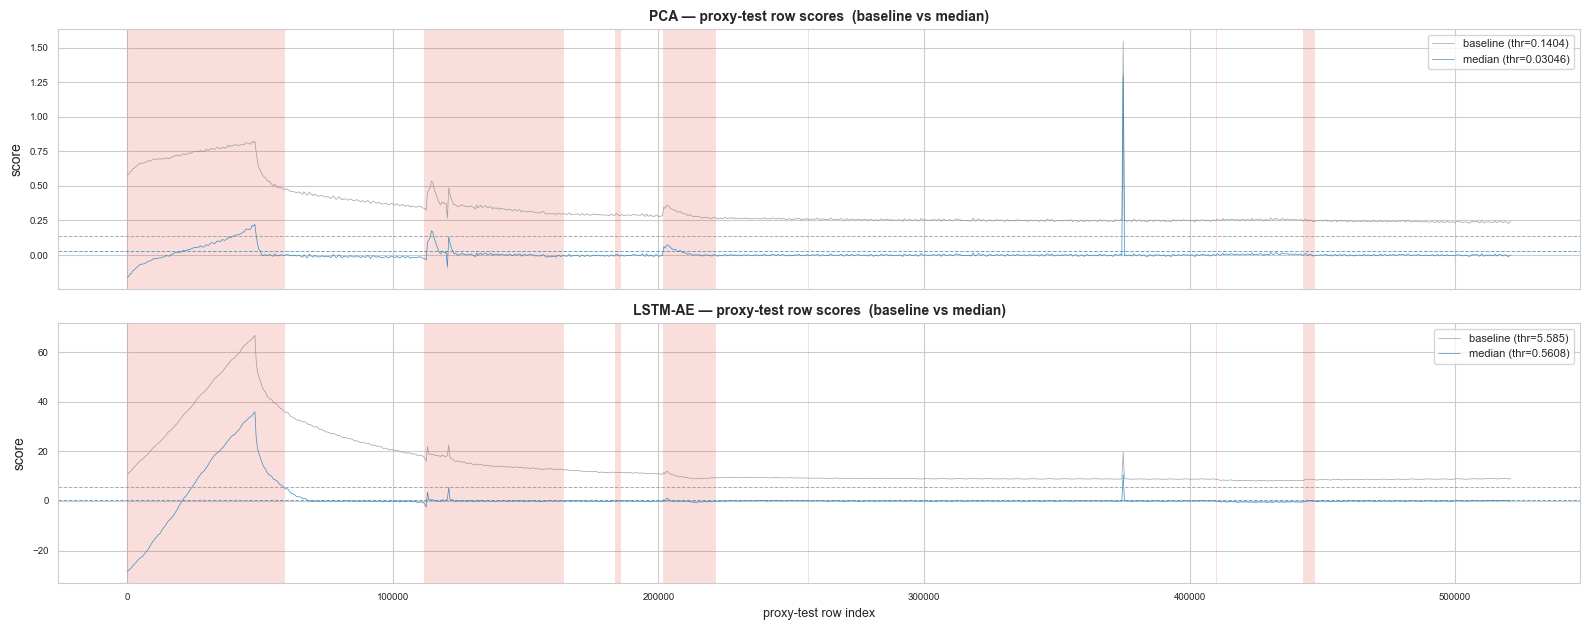

In [6]:
DS = 500
idx = np.arange(0, len(y_proxy), DS)
segs = find_anomaly_segments(y_proxy)

# Threshold lookup per (model, variant)
thr_lookup = {(r['model'], r['variant']): r['threshold'] for r in rows}

fig, axes = plt.subplots(len(MODEL_SPEC), 1, figsize=(16, 3.2 * len(MODEL_SPEC)), sharex=True)
if len(MODEL_SPEC) == 1:
    axes = [axes]

for ax, (name, _model, _topk) in zip(axes, MODEL_SPEC):
    # Best detrended variant for this model (median or zscore, whichever beats baseline most)
    sub = compare[compare['model'] == name]
    best_variant = sub.sort_values('esa_f05', ascending=False)['variant'].iloc[0]
    if best_variant == 'baseline':
        # No detrend beat baseline — still show the median variant as comparison
        best_variant = 'median'

    s_base = scores_proxy[(name, 'baseline')]
    s_det  = scores_proxy[(name, best_variant)]
    thr_base = thr_lookup[(name, 'baseline')]
    thr_det  = thr_lookup[(name, best_variant)]

    ax.plot(idx, s_base[idx], lw=0.5, color='#7f8c8d',      label=f'baseline (thr={thr_base:.4g})', alpha=0.8)
    ax.plot(idx, s_det[idx],  lw=0.5, color=NOMINAL_COLOR,  label=f'{best_variant} (thr={thr_det:.4g})', alpha=0.9)
    ax.axhline(thr_base, color='#7f8c8d',     ls='--', lw=0.7, alpha=0.7)
    ax.axhline(thr_det,  color=NOMINAL_COLOR, ls='--', lw=0.7, alpha=0.7)
    for s in segs:
        ax.axvspan(s['start'], s['end'], color=ANOMALY_COLOR, alpha=0.18, linewidth=0)
    ax.set_title(f'{name} — proxy-test row scores  (baseline vs {best_variant})',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('score'); ax.legend(fontsize=8, loc='upper right')
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('proxy-test row index', fontsize=9)
fig.tight_layout()
plt.show()

## Submission — best performer on real Kaggle test

Nach Review der Ergebnisse oben die Submission auskommentieren und ausführen.
Die Submission verwendet die beste (model, variant) Kombination aus der Vergleichstabelle und schreibt nach `kaggle/submissions/{model}_nb20_{variant}_{ts}.parquet`.


In [7]:
# Submission — nach Review auskommentieren und ausführen
# import time as _t
#
# best_model_name = best_row['model']
# best_variant    = best_row['variant']
# best_threshold  = float(best_row['threshold'])
#
# model_lookup = {n: (m, t) for n, m, t in MODEL_SPEC}
# best_obj, best_topk = model_lookup[best_model_name]
#
# print(f'Scoring Kaggle test with {best_model_name} / {best_variant} ...')
# kaggle_scores = score_variant(best_obj, X_kaggle, best_variant, best_topk)
# y_kaggle      = (kaggle_scores > best_threshold).astype(np.uint8)
# print(f'  positive rate: {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')
#
# ts   = _t.strftime('%Y%m%d_%H%M%S')
# stem = f'{best_model_name.lower().replace("-","_")}_nb20_{best_variant}_{ts}'
# out_path = default_submission_path(stem)
#
# submission = make_submission(
#     predictions     = y_kaggle,
#     test_ids        = test_ids,
#     out_path        = out_path,
#     validate_schema = True,
# )
# print(f'\nSubmission written: {out_path}')
# print(submission_summary(submission))
#
# # nb20_pca_median.parquet
# # Score: 0.454
# # Private score: 0.599
